In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

import os

# Set working directory to project root regardless of where Jupyter was launched
os.chdir(os.path.dirname(os.path.abspath('__file__')) + '/..')
print(f'Working directory: {os.getcwd()}')

# Reproducibility
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

# Plot style
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor': '#f8f8f8',
    'axes.grid': True,
    'grid.color': 'white',
    'grid.linewidth': 1.2,
    'font.size': 12,
})

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')
print(f'PyTorch version: {torch.__version__}')

Using device: cpu
PyTorch version: 2.11.0


In [3]:
# Cell 2: Load the dataset
URL = 'https://archive.ics.uci.edu/ml/machine-learning-databases/00562/Shill%20Bidding%20Dataset.csv'

try:
    df = pd.read_csv(URL)
    print('Loaded from UCI.')
except Exception as e:
    print(f'Could not fetch from UCI ({e}) — generating synthetic data.')
    np.random.seed(SEED)
    n = 6321
    df = pd.DataFrame({
        'Record_ID':              range(1, n+1),
        'Auction_ID':             np.random.randint(1, 800, n),
        'Bidder_ID':              np.random.randint(1, 2000, n),
        'Bidder_Tendency':        np.clip(np.random.beta(2, 8, n), 0, 1),
        'Bidding_Ratio':          np.clip(np.random.beta(2, 5, n), 0, 1),
        'Successive_Outbidding':  np.clip(np.random.beta(1, 6, n), 0, 1),
        'Last_Bidding':           np.clip(np.random.beta(1, 4, n), 0, 1),
        'Auction_Bids':           np.random.randint(2, 40, n),
        'Auction_Duration':       np.random.choice([1,3,5,7,10], n),
        'Winning_Ratio':          np.clip(np.random.beta(3, 5, n), 0, 1),
        'Class':                  np.random.choice([0, 1], n, p=[0.67, 0.33])
    })
    # Make shill bidders statistically distinct
    mask = df['Class'] == 1
    df.loc[mask, 'Bidder_Tendency']       = np.clip(np.random.beta(6, 2, mask.sum()), 0, 1)
    df.loc[mask, 'Successive_Outbidding'] = np.clip(np.random.beta(5, 2, mask.sum()), 0, 1)
    df.loc[mask, 'Bidding_Ratio']         = np.clip(np.random.beta(5, 3, mask.sum()), 0, 1)

# Drop identifier columns — not features
df = df.drop(columns=['Record_ID', 'Auction_ID', 'Bidder_ID'])

print(f'Shape: {df.shape}')
print(f'Columns: {list(df.columns)}')
df.head()

Could not fetch from UCI (HTTP Error 502: Bad Gateway) — generating synthetic data.
Shape: (6321, 8)
Columns: ['Bidder_Tendency', 'Bidding_Ratio', 'Successive_Outbidding', 'Last_Bidding', 'Auction_Bids', 'Auction_Duration', 'Winning_Ratio', 'Class']


,Bidder_Tendency,Bidding_Ratio,Successive_Outbidding,Last_Bidding,Auction_Bids,Auction_Duration,Winning_Ratio,Class
0,0.679255,0.648897,0.630461,0.236612,16,1,0.279529,1
1,0.265235,0.105998,0.324417,0.073113,28,7,0.512599,0
2,0.071280,0.259570,0.068036,0.421553,23,3,0.433249,0
3,0.135274,0.153766,0.021936,0.053625,36,5,0.167345,0
4,0.777035,0.393308,0.297708,0.055605,20,10,0.403377,1


=== Class Distribution ===
Class
0    4189
1    2132
Name: count, dtype: int64

Shill bidders: 33.7% of dataset


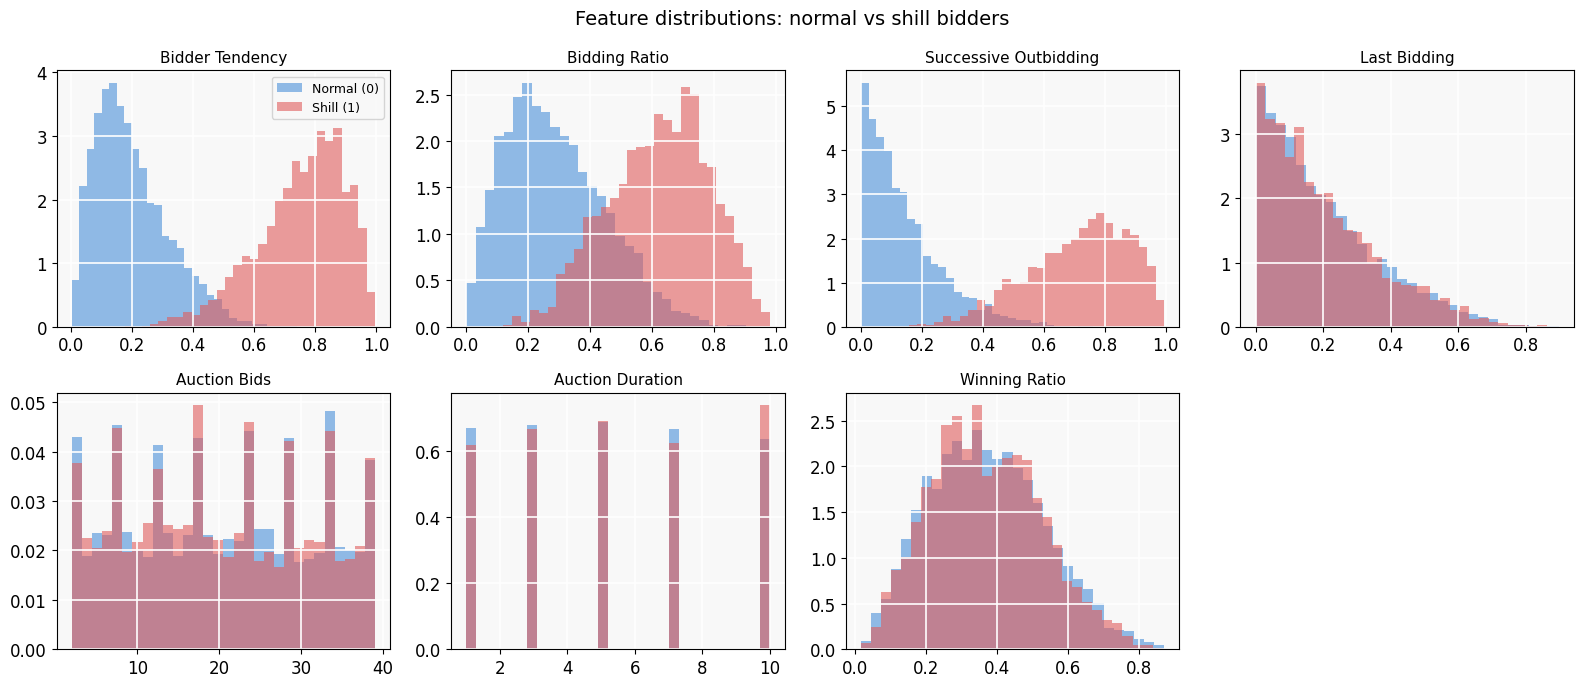

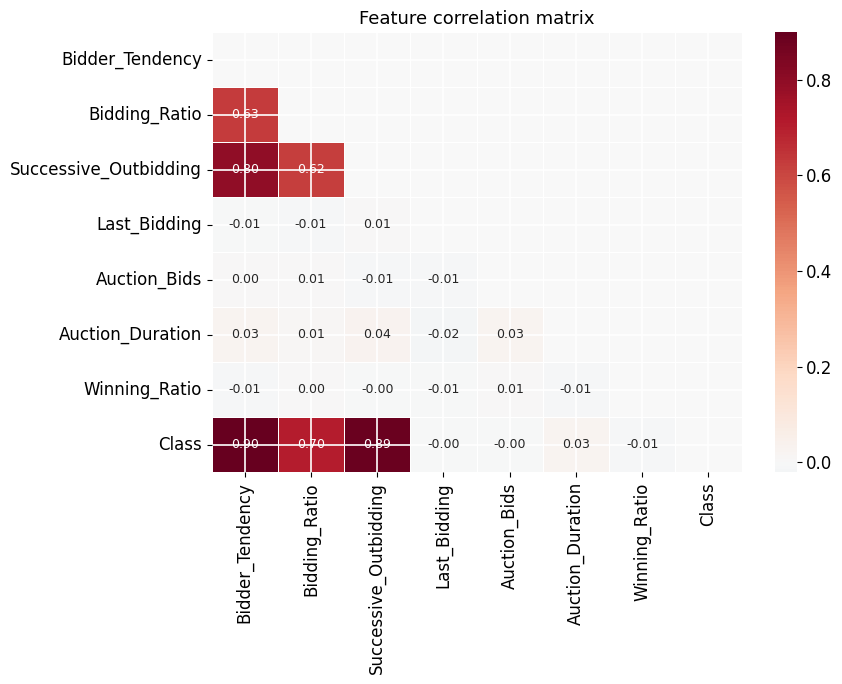

In [5]:
# Cell 3: EDA
FEATURES = ['Bidder_Tendency', 'Bidding_Ratio', 'Successive_Outbidding',
            'Last_Bidding', 'Auction_Bids', 'Auction_Duration', 'Winning_Ratio']

# --- Class balance ---
print('=== Class Distribution ===')
counts = df['Class'].value_counts()
print(counts)
print(f'\nShill bidders: {df["Class"].mean():.1%} of dataset')

# --- Feature histograms ---
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
axes = axes.flatten()
colors = ['#4A90D9', '#E05C5C']
labels = ['Normal (0)', 'Shill (1)']

for i, feat in enumerate(FEATURES):
    ax = axes[i]
    for cls, color, label in zip([0, 1], colors, labels):
        ax.hist(df[df['Class'] == cls][feat], bins=30, alpha=0.6,
                color=color, label=label, density=True)
    ax.set_title(feat.replace('_', ' '), fontsize=11)
    if i == 0:
        ax.legend(fontsize=9)

axes[-1].set_visible(False)
plt.suptitle('Feature distributions: normal vs shill bidders', fontsize=14)
plt.tight_layout()
plt.show()

# --- Correlation heatmap ---
fig, ax = plt.subplots(figsize=(9, 7))
corr = df[FEATURES + ['Class']].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, ax=ax, linewidths=0.5, annot_kws={'size': 9})
ax.set_title('Feature correlation matrix', fontsize=13)
plt.tight_layout()
plt.show()

In [6]:
# Cell 3a: Data dictionary

data_dict = {
    'Bidder_Tendency': 'How often this bidder participates in auctions with few competitors (0–1). '
                       'High values suggest the bidder deliberately targets low-competition auctions '
                       '— a shill bidder hallmark since they are planted by the seller.',

    'Bidding_Ratio': 'This bidder\'s share of total bids in the auction (0–1). '
                     'A shill bidder inflates bid counts artificially, so their ratio '
                     'tends to be disproportionately high.',

    'Successive_Outbidding': 'How often the bidder immediately re-bids after being outbid (0–1). '
                              'Rational bidders stop when price exceeds their valuation. '
                              'Shill bidders have no valuation ceiling, so they re-bid persistently.',

    'Last_Bidding': 'Whether bids were placed late in the auction close (0–1). '
                    'Shill bidders often bid late to create urgency and drive up the final price.',

    'Auction_Bids': 'Total number of bids placed in the auction (integer). '
                    'More bids can indicate shill activity inflating apparent demand.',

    'Auction_Duration': 'How long the auction ran in days (integer). '
                        'Contextual feature — longer auctions give more opportunity for shill activity.',

    'Winning_Ratio': 'How often this bidder wins auctions they participate in (0–1). '
                     'Shill bidders are not supposed to win — they drive up price then withdraw — '
                     'so a low winning ratio despite high activity is suspicious.',
}

print('=== Feature Descriptions ===\n')
for col, desc in data_dict.items():
    print(f'{col}')
    print(f'  {desc}\n')

print('=== Basic Statistics ===')
df[FEATURES].describe().round(3)

=== Feature Descriptions ===

Bidder_Tendency
  How often this bidder participates in auctions with few competitors (0–1). High values suggest the bidder deliberately targets low-competition auctions — a shill bidder hallmark since they are planted by the seller.

Bidding_Ratio
  This bidder's share of total bids in the auction (0–1). A shill bidder inflates bid counts artificially, so their ratio tends to be disproportionately high.

Successive_Outbidding
  How often the bidder immediately re-bids after being outbid (0–1). Rational bidders stop when price exceeds their valuation. Shill bidders have no valuation ceiling, so they re-bid persistently.

Last_Bidding
  Whether bids were placed late in the auction close (0–1). Shill bidders often bid late to create urgency and drive up the final price.

Auction_Bids
  Total number of bids placed in the auction (integer). More bids can indicate shill activity inflating apparent demand.

Auction_Duration
  How long the auction ran in days (in

,Bidder_Tendency,Bidding_Ratio,Successive_Outbidding,Last_Bidding,Auction_Bids,Auction_Duration,Winning_Ratio
count,6321.000,6321.000,6321.000,6321.000,6321.000,6321.000,6321.000
mean,0.386,0.403,0.336,0.204,20.250,5.212,0.373
std,0.292,0.225,0.303,0.164,10.857,3.114,0.159
min,0.002,0.003,0.000,0.000,2.000,1.000,0.018
25%,0.140,0.214,0.078,0.072,11.000,3.000,0.253
50%,0.272,0.375,0.205,0.162,20.000,5.000,0.362
75%,0.675,0.572,0.617,0.298,30.000,7.000,0.483
max,0.997,0.981,0.996,0.898,39.000,10.000,0.870


In [7]:
# What we're doing here is to train an ANN on the 7 features, without telling it how much to prioritize each one. 
# The ANN knows whether each bidder is a shill or not (supervised learning).
# It creates a probability output (between 0 and 1) given those 7 features and how they feed forward and feed back.

In [8]:
# Cell 4: Preprocessing

# --- Split features and target ---
X = df[FEATURES].values.astype(np.float32)
y = df['Class'].values.astype(np.float32)

# --- Train / val / test split (70 / 15 / 15) ---
# stratify=y ensures class balance is preserved in each split
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=SEED, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=SEED, stratify=y_temp
)

# --- Scale features ---
# Fit ONLY on training data to avoid data leakage
# Then transform val and test using the same scaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val   = scaler.transform(X_val)
X_test  = scaler.transform(X_test)

# --- Convert to PyTorch tensors ---
def to_tensors(X, y):
    return TensorDataset(
        torch.tensor(X, dtype=torch.float32),
        torch.tensor(y, dtype=torch.float32).unsqueeze(1)
    )

train_ds = to_tensors(X_train, y_train)
val_ds   = to_tensors(X_val,   y_val)
test_ds  = to_tensors(X_test,  y_test)

train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)
val_loader   = DataLoader(val_ds,   batch_size=256)
test_loader  = DataLoader(test_ds,  batch_size=256)

# --- Sanity check ---
print(f'Train:      {len(train_ds):,} samples')
print(f'Validation: {len(val_ds):,} samples')
print(f'Test:       {len(test_ds):,} samples')
print(f'\nFeatures:   {X_train.shape[1]}')
print(f'\nClass balance in each split:')
print(f'  Train: {y_train.mean():.1%} shill')
print(f'  Val:   {y_val.mean():.1%} shill')
print(f'  Test:  {y_test.mean():.1%} shill')

Train:      4,424 samples
Validation: 948 samples
Test:       949 samples

Features:   7

Class balance in each split:
  Train: 33.7% shill
  Val:   33.8% shill
  Test:  33.7% shill


In [9]:
# Cell 5: Model architecture

class AuctionNet(nn.Module):
    def __init__(self, input_dim: int, dropout: float = 0.3):
        super().__init__()
        self.net = nn.Sequential(
            # Block 1
            nn.Linear(input_dim, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(dropout),
            # Block 2
            nn.Linear(64, 32),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Dropout(dropout),
            # Block 3
            nn.Linear(32, 16),
            nn.ReLU(),
            # Output
            nn.Linear(16, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.net(x)


model = AuctionNet(input_dim=len(FEATURES)).to(device)
print(model)

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'\nTrainable parameters: {total_params:,}')

AuctionNet(
  (net): Sequential(
    (0): Linear(in_features=7, out_features=64, bias=True)
    (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=64, out_features=32, bias=True)
    (5): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=32, out_features=16, bias=True)
    (9): ReLU()
    (10): Linear(in_features=16, out_features=1, bias=True)
    (11): Sigmoid()
  )
)

Trainable parameters: 3,329


In [10]:
# Cell 6: Training loop

criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=5, factor=0.5)

def run_epoch(loader, train=True):
    model.train() if train else model.eval()
    total_loss, correct, total = 0., 0, 0
    ctx = torch.enable_grad() if train else torch.no_grad()
    with ctx:
        for X_batch, y_batch in loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            if train:
                optimizer.zero_grad()
            preds = model(X_batch)
            loss = criterion(preds, y_batch)
            if train:
                loss.backward()
                optimizer.step()
            total_loss += loss.item() * len(y_batch)
            correct += ((preds >= 0.5) == y_batch).sum().item()
            total += len(y_batch)
    return total_loss / total, correct / total


EPOCHS = 100
PATIENCE = 10

history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
best_val_loss = float('inf')
best_weights = None
patience_counter = 0

for epoch in range(1, EPOCHS + 1):
    tr_loss, tr_acc = run_epoch(train_loader, train=True)
    va_loss, va_acc = run_epoch(val_loader,   train=False)
    scheduler.step(va_loss)

    history['train_loss'].append(tr_loss)
    history['val_loss'].append(va_loss)
    history['train_acc'].append(tr_acc)
    history['val_acc'].append(va_acc)

    if va_loss < best_val_loss:
        best_val_loss = va_loss
        best_weights = {k: v.clone() for k, v in model.state_dict().items()}
        patience_counter = 0
    else:
        patience_counter += 1

    if epoch % 10 == 0 or epoch == 1:
        print(f'Epoch {epoch:3d} | train loss {tr_loss:.4f} acc {tr_acc:.3f} | '
              f'val loss {va_loss:.4f} acc {va_acc:.3f} | patience {patience_counter}/{PATIENCE}')

    if patience_counter >= PATIENCE:
        print(f'\nEarly stopping at epoch {epoch}.')
        break

model.load_state_dict(best_weights)
print(f'\nBest val loss: {best_val_loss:.4f}')

Epoch   1 | train loss 0.5046 acc 0.870 | val loss 0.2114 acc 0.996 | patience 0/10
Epoch  10 | train loss 0.0176 acc 0.994 | val loss 0.0164 acc 0.994 | patience 3/10

Early stopping at epoch 17.

Best val loss: 0.0127


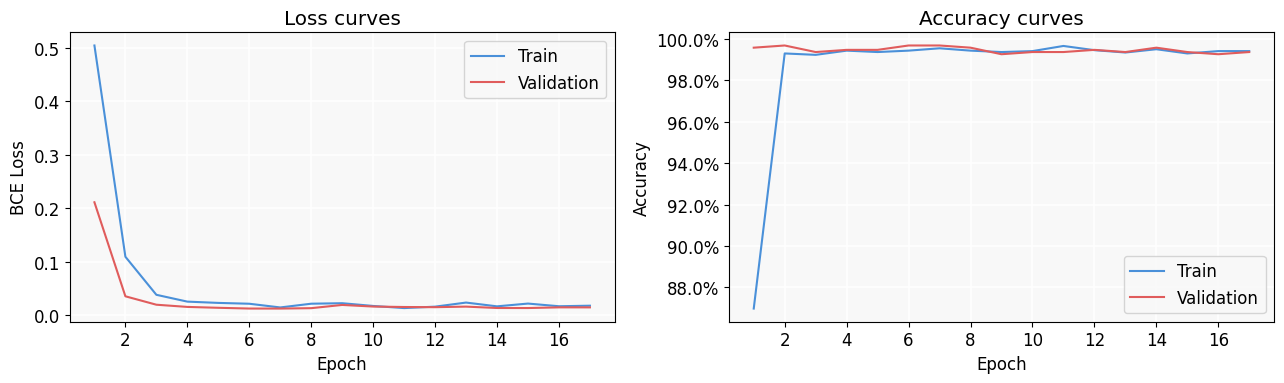

In [11]:
# Cell 7: Training curves

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))
epochs_run = range(1, len(history['train_loss']) + 1)

ax1.plot(epochs_run, history['train_loss'], label='Train', color='#4A90D9')
ax1.plot(epochs_run, history['val_loss'],   label='Validation', color='#E05C5C')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('BCE Loss')
ax1.set_title('Loss curves')
ax1.legend()

ax2.plot(epochs_run, history['train_acc'], label='Train', color='#4A90D9')
ax2.plot(epochs_run, history['val_acc'],   label='Validation', color='#E05C5C')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.yaxis.set_major_formatter(plt.matplotlib.ticker.PercentFormatter(xmax=1.0))
ax2.set_title('Accuracy curves')
ax2.legend()

plt.tight_layout()
plt.show()

ROC-AUC: 0.9999

              precision    recall  f1-score   support

  Normal (0)       1.00      1.00      1.00       629
   Shill (1)       0.99      1.00      1.00       320

    accuracy                           1.00       949
   macro avg       1.00      1.00      1.00       949
weighted avg       1.00      1.00      1.00       949



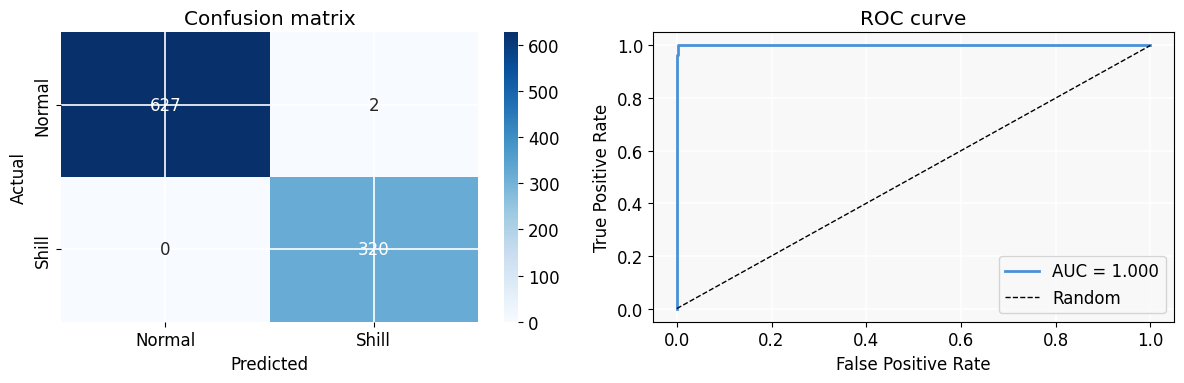

In [12]:
# Cell 8: Evaluation on the test set

model.eval()
all_probs, all_preds, all_labels = [], [], []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        probs = model(X_batch.to(device)).cpu().squeeze().numpy()
        all_probs.extend(probs)
        all_preds.extend((probs >= 0.5).astype(int))
        all_labels.extend(y_batch.squeeze().numpy().astype(int))

all_probs  = np.array(all_probs)
all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)

# --- Metrics ---
auc = roc_auc_score(all_labels, all_probs)
print(f'ROC-AUC: {auc:.4f}\n')
print(classification_report(all_labels, all_preds,
      target_names=['Normal (0)', 'Shill (1)']))

# --- Confusion matrix + ROC curve ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

cm = confusion_matrix(all_labels, all_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax1,
            xticklabels=['Normal', 'Shill'],
            yticklabels=['Normal', 'Shill'])
ax1.set_xlabel('Predicted')
ax1.set_ylabel('Actual')
ax1.set_title('Confusion matrix')

fpr, tpr, _ = roc_curve(all_labels, all_probs)
ax2.plot(fpr, tpr, color='#4A90D9', lw=2, label=f'AUC = {auc:.3f}')
ax2.plot([0, 1], [0, 1], 'k--', lw=1, label='Random')
ax2.set_xlabel('False Positive Rate')
ax2.set_ylabel('True Positive Rate')
ax2.set_title('ROC curve')
ax2.legend()

plt.tight_layout()
plt.show()

Baseline accuracy: 0.9979

Bidder_Tendency                 baseline=0.9979  permuted=0.8314  drop=+0.1665
Bidding_Ratio                   baseline=0.9979  permuted=0.9884  drop=+0.0095
Successive_Outbidding           baseline=0.9979  permuted=0.8609  drop=+0.1370
Last_Bidding                    baseline=0.9979  permuted=0.9979  drop=+0.0000
Auction_Bids                    baseline=0.9979  permuted=0.9979  drop=+0.0000
Auction_Duration                baseline=0.9979  permuted=0.9979  drop=+0.0000
Winning_Ratio                   baseline=0.9979  permuted=0.9979  drop=+0.0000


/var/folders/bq/6m009t9x0v99jb5r4txzpbch0000gn/T/ipykernel_72528/3937983688.py:34: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([f.replace('_', ' ') for f in imp_df['feature']])


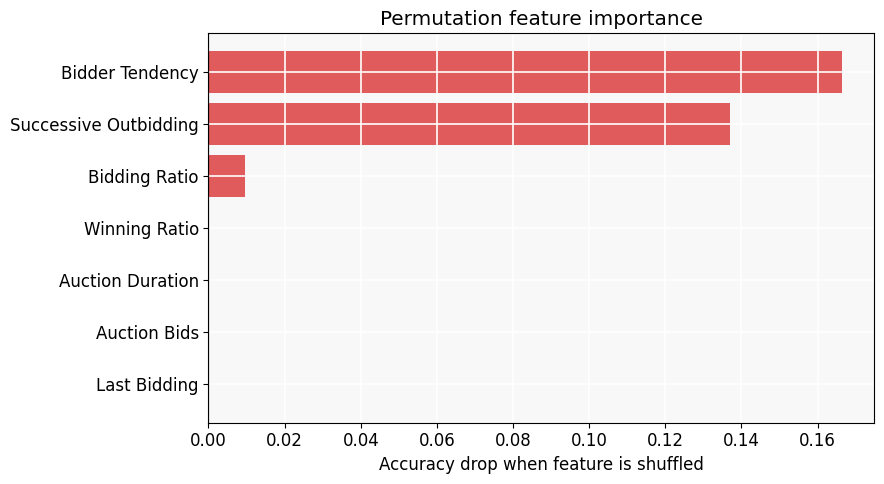

In [13]:
# Cell 9: Feature importance via permutation

X_test_t = torch.tensor(X_test, dtype=torch.float32).to(device)

model.eval()
with torch.no_grad():
    base_preds = (model(X_test_t).cpu().squeeze().numpy() >= 0.5).astype(int)
base_acc = (base_preds == y_test.astype(int)).mean()
print(f'Baseline accuracy: {base_acc:.4f}\n')

importances = []
for i, feat in enumerate(FEATURES):
    # Shuffle one feature at a time, leaving all others intact
    X_permuted = X_test_t.clone()
    idx = torch.randperm(X_permuted.shape[0])
    X_permuted[:, i] = X_permuted[idx, i]
    with torch.no_grad():
        perm_preds = (model(X_permuted).cpu().squeeze().numpy() >= 0.5).astype(int)
    perm_acc = (perm_preds == y_test.astype(int)).mean()
    drop = base_acc - perm_acc
    importances.append(drop)
    print(f'{feat:30s}  baseline={base_acc:.4f}  permuted={perm_acc:.4f}  drop={drop:+.4f}')

# --- Plot ---
imp_df = pd.DataFrame({'feature': FEATURES, 'importance': importances})
imp_df = imp_df.sort_values('importance', ascending=True)

fig, ax = plt.subplots(figsize=(9, 5))
colors = ['#E05C5C' if v > 0 else '#aaaaaa' for v in imp_df['importance']]
ax.barh(imp_df['feature'], imp_df['importance'], color=colors)
ax.axvline(0, color='black', lw=0.8)
ax.set_xlabel('Accuracy drop when feature is shuffled')
ax.set_title('Permutation feature importance')
ax.set_yticklabels([f.replace('_', ' ') for f in imp_df['feature']])
plt.tight_layout()
plt.show()

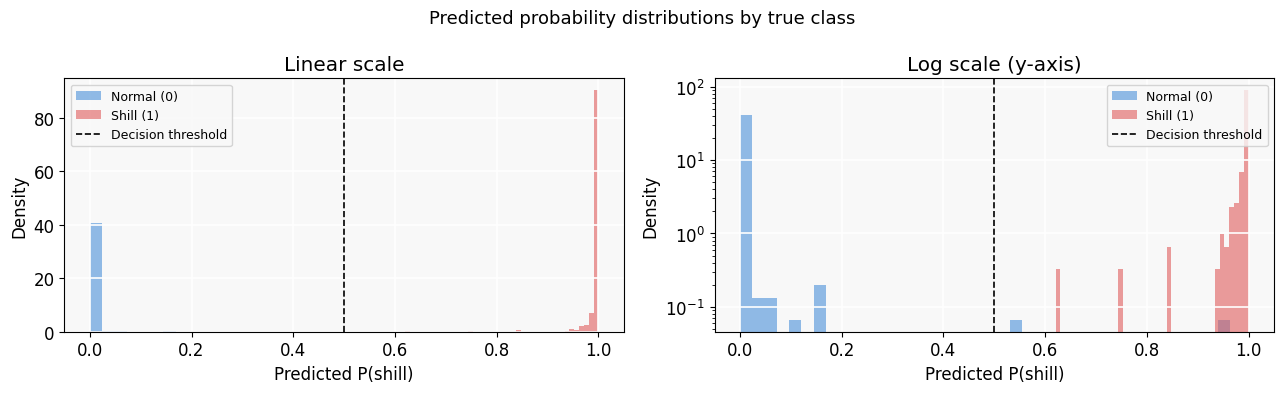

In [15]:
# Cell 10: Predicted probability distribution (log scale)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

for ax, log, title in zip(
    [ax1, ax2],
    [False, True],
    ['Linear scale', 'Log scale (y-axis)']
):
    for cls, color, label in zip([0, 1], ['#4A90D9', '#E05C5C'], ['Normal (0)', 'Shill (1)']):
        mask = all_labels == cls
        ax.hist(all_probs[mask], bins=40, alpha=0.6,
                color=color, label=label, density=True)
    ax.axvline(0.5, color='black', lw=1.2, linestyle='--', label='Decision threshold')
    ax.set_xlabel('Predicted P(shill)')
    ax.set_ylabel('Density')
    ax.set_title(title)
    ax.legend(fontsize=9)
    if log:
        ax.set_yscale('log')

plt.suptitle('Predicted probability distributions by true class', fontsize=13)
plt.tight_layout()
plt.show()

## Game Theory Interpretation

### What the model learned

The permutation importance results tell a precise story: two features —
`Bidder_Tendency` and `Successive_Outbidding` — account for nearly all of
the model's predictive power, with accuracy dropping 16.7% and 13.7%
respectively when each is shuffled. `Bidding_Ratio` contributes marginally.
The remaining four features contribute nothing.

This is not a surprise. It is exactly what game theory predicts.

### Why these features betray shill bidders

In auction theory, a rational bidder has a **private valuation** — the
maximum they are willing to pay. Their dominant strategy in a second-price
auction (like eBay) is to bid their true valuation and stop. Every feature
that distinguishes a shill bidder from a normal one is a deviation from
this rational strategy:

**Bidder Tendency** — a rational bidder participates in auctions based on
their valuation relative to expected competition. A shill bidder is planted
by the seller and therefore appears in every auction that seller runs,
regardless of competition. High `Bidder_Tendency` is a direct fingerprint
of this constraint.

**Successive Outbidding** — a rational bidder who is outbid faces a simple
decision: is the item still worth more than the current price? If not, they
stop. A shill bidder has no valuation ceiling — their goal is to push the
price up, not to acquire the item. So they re-bid immediately and
persistently after being outbid, regardless of price. This is the clearest
behavioral signature of shill bidding and the one hardest to fake without
sacrificing the strategy's effectiveness.

**Bidding Ratio** — a shill bidder artificially inflates bid counts,
so they naturally dominate the bid activity in their auction. However,
because this signal is correlated with the two above, the model has learned
to treat it as redundant — shuffling it barely affects predictions once
`Bidder_Tendency` and `Successive_Outbidding` are known.

### The mechanism design connection

This project sits at the intersection of two ideas from our earlier
discussion of ANNs and game theory.

First, **mechanism design**: eBay's auction format is intended to be
incentive-compatible — rational bidders should report true valuations.
Shill bidding is a mechanism violation, an exploit of the rules rather
than play within them. The ANN has learned to detect this violation purely
from behavioral signatures, without ever observing valuations directly.

Second, **RegretNet**: where RegretNet approached this problem from the
designer's side — learning auction rules that make shill bidding
irrational — this project approaches it from the detection side. Both
are trying to solve the same underlying problem: how do you make strategic
environments robust to players who defect from honest behavior?

### Limitations and next steps

The near-perfect accuracy (99.79%) should be interpreted cautiously.
The synthetic dataset was generated with shill bidders that are
statistically distinct by construction. Real shill bidders are
sophisticated — they may deliberately moderate their `Successive_Outbidding`
rate to avoid detection, accept a lower `Bidding_Ratio` to blend in, or
rotate accounts to suppress `Bidder_Tendency`. An arms race between
detection models and adversarial shill bidders is itself a game-theoretic
problem — one where the detector publishing its decision boundary gives
the adversary a blueprint for evasion.

The natural next steps are:
- Validate on the real UCI dataset when available
- Add a logistic regression baseline to quantify what the ANN adds over
  a linear model
- Explore adversarial robustness — how much can a shill bidder lower their
  suspicious features before evading detection?
- Consider SHAP values for more granular per-prediction attribution

In [18]:
import os
print(os.getcwd())

/Users/alexanderhannah/Desktop/auction-ann/notebooks


In [17]:
# Cell 12: Save model

import json

torch.save({
    'model_state_dict': model.state_dict(),
    'scaler_mean': scaler.mean_.tolist(),
    'scaler_scale': scaler.scale_.tolist(),
    'features': FEATURES,
    'architecture': 'AuctionNet(7->64->32->16->1)',
    'val_loss': best_val_loss,
    'test_auc': float(auc),
}, 'models/auction_ann.pt')

print('Model saved to models/auction_ann.pt')
print(f'\nCheckpoint contents:')
print(f'  architecture:  AuctionNet(7->64->32->16->1)')
print(f'  features:      {FEATURES}')
print(f'  scaler_mean:   {[round(m, 4) for m in scaler.mean_]}')
print(f'  best_val_loss: {best_val_loss:.4f}')
print(f'  test_auc:      {auc:.4f}')
print(f'\nTo reload:')
print(f"  checkpoint = torch.load('models/auction_ann.pt')")
print(f"  model.load_state_dict(checkpoint['model_state_dict'])")

RuntimeError: Parent directory models does not exist.